# Question 2

## Market analysis on the fund data given via email

In [1]:
#imports
import pandas as pd
import statsmodels.api as sm
import os
import matplotlib.pyplot as plt

## 2.1

### multilinear regression model and alpha and beta calculations

In [2]:
#read the file

from ast import In


df = pd.read_excel("../Data/data.xlsx", sheet_name="returns data")

#print(df.head())
#print(df.columns)

#remove missings vals
df = df.dropna()

# we are trying to predict returns so we set this as our y
y = df['Hedge Fund']
#print(y)

# define festures from teh columns

df.columns = df.columns.str.strip()
factor_columns = [
    'Factor - Low Risk',
    'Factor - Value vs Growth',
    'Factor - Fixed Income Carry',
    'Factor - Local Equity',
    'Factor - Trend Following',
    'Factor - Commodities',
    'Factor - Equity',
    'Factor - Foreign Exchange Carry',
    'Factor - Small Cap',
    'Factor - Emerging Markets',
    'Factor - Foreign Currency',
    'Factor - Local Inflation',
    'Factor - Equity Short Volatility',
    'Factor - Credit',
    'Factor - Interest Rates',
    'Factor - Crowding',
    'Factor - Momentum',
    'Factor - Quality',
]

#test to get the names exact as panda see them
#for col in df.columns:
    #print(repr(col))

x = df[factor_columns]
#print(x)
x = sm.add_constant(x) #allows for the alpha term

# fit an ols regression model
model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Hedge Fund   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.178
Method:                 Least Squares   F-statistic:                     3.336
Date:                Wed, 17 Jun 2026   Prob (F-statistic):           1.88e-05
Time:                        10:19:01   Log-Likelihood:                 438.67
No. Observations:                 195   AIC:                            -839.3
Df Residuals:                     176   BIC:                            -777.2
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

- the code above relates to the data provided and gives an initial set up and summary to an OLS regression model for the data that can predict returns based off of all of the factors it is given, e.g low risk factor, emerging markets factor etc
- the model creates a calculation in the form $ returns = \beta^T x + \alpha + \epsilon $, where $\epsilon$ is the random noise
- initially this gives us an alpha value of 0.0065 meaning that the manager is returning 0.65% on top of the market each month

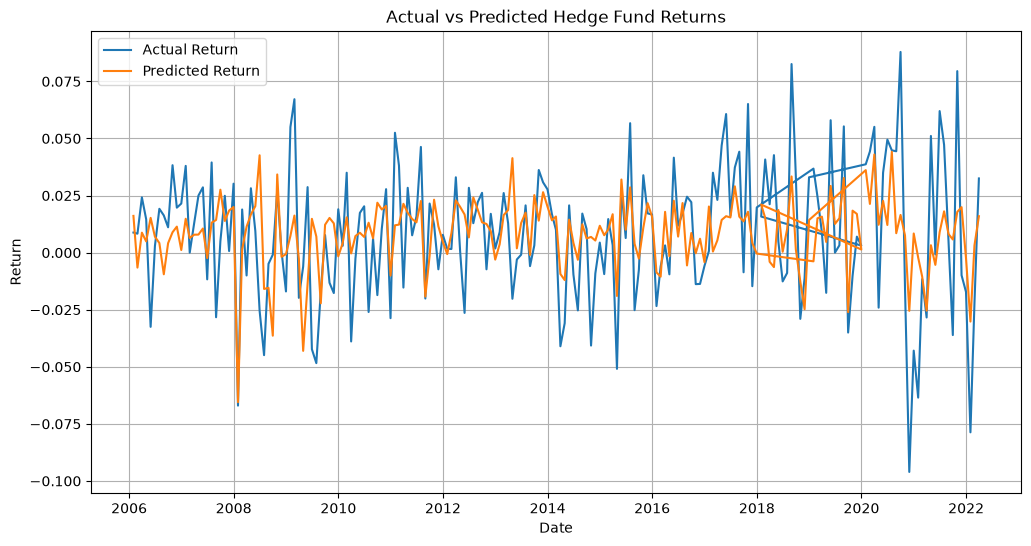

In [3]:
#visual analysis
df["predicted_returns"] = model.predict(x)

plt.figure(figsize=(12, 6))

plt.plot(
    df["perf_date"],
    df["Hedge Fund"],
    label="Actual Return"
)

plt.plot(
    df["perf_date"],
    df["predicted_returns"],
    label="Predicted Return"
)

plt.title("Actual vs Predicted Hedge Fund Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)

plt.show()



The factor model explains approximately 25% of the variation in the fund's returns ($ R^2 = 0.254 $). While this indicates that the selected factors have some explanatory power, a large proportion of the return variation remains unexplained. The model F-statistic of 3.336, together with a near-zero F-test p-value, suggests that the factors are collectively significant and contribute meaningfully to explaining fund returns. However, the relatively low R
2
 indicates that additional factors or manager-specific effects may also be influencing performance.

The estimated monthly alpha is 0.0065. Annualising this gives:
$$
(1+0.0065)
12
−1≈0.081
$$

corresponding to an annual alpha of approximately 8.1%. This is a strong level of excess return after controlling for the included factor exposures. Furthermore, the alpha estimate is statistically significant, with a p-value of 0.004 and a t-statistic of 2.88, providing strong evidence that the alpha is different from zero.

The factor exposures (betas) are generally small, with the largest exposure being to the Credit factor ($\beta ≈ 0.22 $). Several factors, including Emerging Markets and Commodities, exhibit slightly negative betas, suggesting that the fund has historically tended to move modestly opposite to these factor returns. The absence of large factor exposures indicates that the fund is not heavily driven by any single systematic risk factor.

Overall, the results suggest that the fund's performance is not primarily explained by the selected factor set and that it has generated statistically significant positive alpha. While this is consistent with manager skill or unique investment decisions, further analysis would be required to determine whether the alpha is persistent and whether additional risk factors could explain some of the currently unexplained returns.

### 2.3

In [20]:
# sharpe ratio to determine if the returns are good for the levelof risk being taken
fund_returns = df["Hedge Fund"].mean()

fund_volatility = df["Hedge Fund"].std()

#risk free rates obtained from Sonia rates from the period 2006 - 2022
df_rf = pd.read_excel("../Data/Sonia.xlsx", header = 1)
#for col in df_rf.columns:
#    print(repr(col))
risk_free_rate_anual = df_rf['Daily Sterling overnight index average (SONIA) rate              [a]             IUDSOIA'].mean() / 100 #convert %
risk_free_rate = risk_free_rate_anual / 12 #convert to monthly

print("Mean monthly return:", fund_returns)
print("Monthly volatility:", fund_volatility)
print("Monthly risk free:", risk_free_rate)
sharpe_ratio = (fund_returns - risk_free_rate) / fund_volatility
print("Sharpe Ratio monthly:", sharpe_ratio)
print("Sharpe Ratio annualised:", sharpe_ratio * (12 ** 0.5))

Mean monthly return: 0.008425785486153846
Monthly volatility: 0.02962271162987123
Monthly risk free: 0.001064906286379511
Sharpe Ratio monthly: 0.2484876905175589
Sharpe Ratio annualised: 0.8607866100637263


In [21]:
# synthetic data to compare fund vs underlying assets 

betas = model.params.drop("const") #removes alpha

#take the dot product of the betas and the factors to get the returns without the alpha from the fund
synthetic_returns = x.drop(columns=["const"]).dot(betas)

#print(synthetic_returns)
synthetic_fund_mean = synthetic_returns.mean()
synthetic_fund_volatility = synthetic_returns.std()

synthetic_sharpe_ratio = (synthetic_fund_mean - risk_free_rate) / synthetic_fund_volatility
print("Synthetic Fund Mean monthly return:", synthetic_fund_mean)
print("Synthetic Fund Monthly volatility:", synthetic_fund_volatility)
print("Synthetic Fund Sharpe Ratio monthly:", synthetic_sharpe_ratio)
print("Synthetic Fund Sharpe Ratio annualised:", synthetic_sharpe_ratio * (12 ** 0.5))

Synthetic Fund Mean monthly return: 0.0019223941371617486
Synthetic Fund Monthly volatility: 0.014940391368507418
Synthetic Fund Sharpe Ratio monthly: 0.0573939349801586
Synthetic Fund Sharpe Ratio annualised: 0.19881842286387866


The factor-replicating portfolio generated an annual return of approximately 2.3% with an annualised Sharpe ratio of 0.20. In contrast, the hedge fund generated an annual return of approximately 10.6% with an annualised Sharpe ratio of 0.86. Although the fund exhibited higher volatility than the synthetic portfolio, the increase in return was proportionally much larger than the increase in risk, resulting in superior risk adjusted performance. The difference in annual returns between the fund and the synthetic portfolio is approximately 8%, which closely matches the estimated annual alpha obtained from the factor regression. This suggests that the manager adds value beyond simple exposure to the identified risk factors and that an investor would likely have benefited from investing in the fund rather than attempting to replicate the factor exposures directly.

### 2.5

to determine if the betas are stationary the data can be split in half and the same analysis is applied to it as before. the comparison between these beta values for the first vs second half can show whether the betas are stationary or not, so if the fund stratagy has changed or stayed similar

In [26]:
#split the data from the middle
midpoint = len(df) // 2

df_first = df.iloc[:midpoint]
df_second = df.iloc[midpoint:]

model_first = sm.OLS(
    df_first["Hedge Fund"],
    sm.add_constant(df_first[factor_columns])
).fit()

model_second = sm.OLS(
    df_second["Hedge Fund"],
    sm.add_constant(df_second[factor_columns])
).fit()

#print(model_first.summary())
#print(model_second.summary())

coef_comparison = pd.DataFrame({
    "First Half": model_first.params,
    "Second Half": model_second.params
})

coef_comparison["Difference"] = (
    coef_comparison["First Half"]
    - coef_comparison["Second Half"]
)

print(coef_comparison)

                                  First Half  Second Half  Difference
const                               0.010985     0.003616    0.007370
Factor - Low Risk                   0.129288    -0.220608    0.349896
Factor - Value vs Growth           -0.586133     0.000001   -0.586134
Factor - Fixed Income Carry         0.068526    -0.073989    0.142515
Factor - Local Equity              -0.030834    -0.060790    0.029956
Factor - Trend Following            0.027170    -0.348537    0.375708
Factor - Commodities               -0.113270     0.006423   -0.119694
Factor - Equity                    -0.018998     0.002503   -0.021501
Factor - Foreign Exchange Carry     0.020241     0.203435   -0.183194
Factor - Small Cap                 -0.193086    -0.182206   -0.010880
Factor - Emerging Markets          -0.095705    -0.196610    0.100905
Factor - Foreign Currency          -0.002125     0.103203   -0.105329
Factor - Local Inflation           -0.023859    -0.122195    0.098336
Factor - Equity Shor

The table above compares the estimated alpha and factor betas for the first half of the sample period (2006-2014) and the second half (2014-2022). The results show that several factor exposures changed materially between the two periods. In particular, large changes can be observed in the Momentum, Quality and Value vs Growth factors. This suggests that the fund's factor exposures are not stationary and that the manager has altered the portfolio's strategy through time rather than maintaining constant exposures.

One possible explanation is that the manager actively reallocates capital towards factors that they believe will be more profitable under prevailing market conditions. From a risk perspective, non-stationary betas imply that the fund's risk profile changes over time. As a result, historical beta estimates may not be reliable predictors of future factor exposures, making future performance and risk harder to forecast. This also reduces the reliability of a single factor model estimated over the entire sample period, since the model assumes constant exposures throughout the sample